In [8]:
# Import libraries
import fastcore.all as fca
import fastai.vision.all as fva

In [9]:
# Define path to the image data
path = 'data/'

In [10]:
# Create fastai data block to ingest the training and validation images
farm_animals = fva.DataBlock(
    blocks=(fva.ImageBlock, fva.CategoryBlock), 
    get_items=fva.get_image_files, 
    splitter=fva.RandomSplitter(valid_pct=0.2, seed=42),
    get_y=fva.parent_label,
    item_tfms=fva.Resize(128)
)

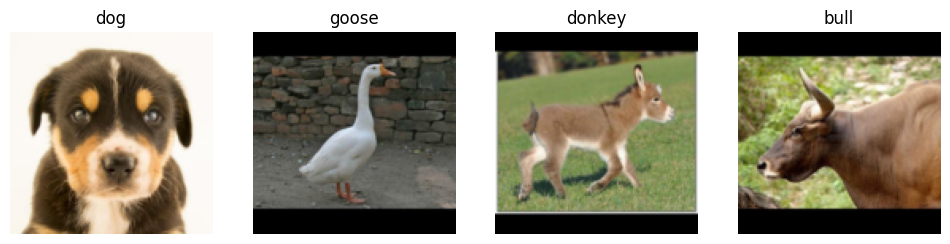

In [11]:
# Create data loaders and display several images
dls = farm_animals.dataloaders(path)
dls.valid.show_batch(max_n=4, nrows=1)

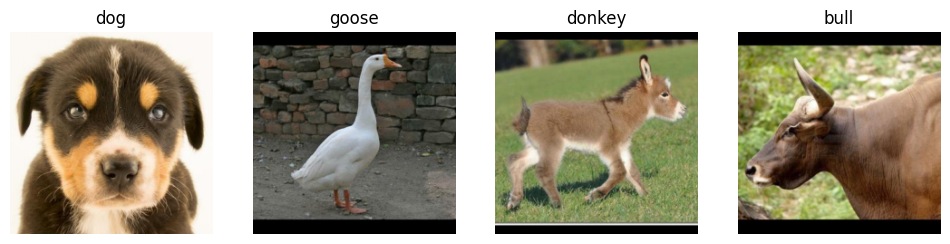

In [12]:
# Randomize cropping of every image and augment the dataset
farm_animals.new(
    item_tfms=fva.RandomResizedCrop(224, min_scale=0.5),
    batch_tfms=fva.aug_transforms()
)

# Create dataloaders
dls = farm_animals.dataloaders(path)

# Display a couple of images after the transofrmation
dls.valid.show_batch(max_n=4, nrows=1)

In [13]:
# Train initial model
model = fva.vision_learner(dls, fva.resnet18, metrics=fva.error_rate)
model.fine_tune(4)

epoch,train_loss,valid_loss,error_rate,time
0,2.883870,0.705292,0.236842,01:25


epoch,train_loss,valid_loss,error_rate,time
0,0.877453,0.550181,0.167763,03:01
1,0.725321,0.501231,0.141447,03:18
2,0.564789,0.494226,0.144737,03:20
3,0.444750,0.481348,0.154605,03:26
